In [1]:
# 05_scoring.ipynb
# 목적: 다중 신호 통합 → 최종 리스크 점수 계산

import pandas as pd
import numpy as np
import os

# 저장된 데이터 전부 불러오기
data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")

prices      = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
macro       = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)
risk = pd.read_csv(f"{data_path}/risk_metrics.csv", index_col=0)
sentiment   = pd.read_csv(f"{data_path}/sentiment_scores.csv")
regime      = pd.read_csv(f"{data_path}/regime_states.csv", parse_dates=["date"])

returns = prices.pct_change().dropna()

print("전체 데이터 로드 완료")
print(f"  주가:     {prices.shape}")
print(f"  거시경제: {macro.shape}")
print(f"  리스크:   {risk.shape}")
print(f"  감성:     {sentiment.shape}")
print(f"  국면:     {regime.shape}")

전체 데이터 로드 완료
  주가:     (2138, 5)
  거시경제: (2123, 2)
  리스크:   (5, 4)
  감성:     (5, 3)
  국면:     (2102, 3)


In [2]:
# 날짜 기준으로 전체 데이터 합치기
regime = regime.set_index("date")

# 주가 + 거시경제 + 국면 합치기
combined = returns.join(macro, how="inner")
combined = combined.join(regime[["regime", "regime_label"]], how="inner")
combined = combined.dropna()

print(f"통합 데이터: {combined.shape}")
print(f"기간: {combined.index[0].date()} ~ {combined.index[-1].date()}")
combined.tail()

통합 데이터: (2102, 9)
기간: 2018-01-31 ~ 2026-07-06


,AAPL,GOOGL,JPM,MSFT,SOXX,VIX,Spread,regime,regime_label
Date,,,,,,,,,
2026-06-29,-0.007189,0.048193,0.001033,-0.011797,0.041377,17.65,0.28,1,Elevated
2026-06-30,0.027046,0.010519,-0.006254,0.012074,0.042989,16.45,0.30,1,Elevated
2026-07-01,0.017349,0.010745,0.020591,0.030186,-0.064080,16.59,0.31,1,Elevated
2026-07-02,0.048407,-0.003599,0.001197,0.016160,-0.055661,16.15,0.35,1,Elevated
2026-07-06,0.013058,0.018199,0.014266,-0.009603,0.026822,15.57,0.35,1,Elevated


In [3]:
# 핵심: 국면별 동적 가중치로 리스크 점수 계산
def calculate_risk_score(row, sentiment_today):
    """
    국면에 따라 가중치를 동적으로 바꿔서 리스크 점수 계산
    - 0 (Normal)   → 감성 위주
    - 1 (Elevated) → 균등
    - 2 (Crisis)   → VIX + 변동성 위주
    """
    regime = row["regime"]

    # 포트폴리오 평균 수익률 변동성 (4종목 평균)
    port_vol = abs(row[["AAPL", "GOOGL", "JPM", "MSFT"]].mean())

    # VIX 정규화 (0~1 사이로)
    vix_norm = min(row["VIX"] / 80, 1.0)

    # 감성 점수 정규화 (−1~+1 → 0~1, 부정일수록 높게)
    sentiment_norm = (1 - sentiment_today) / 2

    # 국채 스프레드 리스크 (역전될수록 위험)
    spread_risk = 1 if row["Spread"] < 0 else 0

    # 국면별 가중치
    if regime == 0:    # Normal
        weights = {"sentiment": 0.40, "vix": 0.25, "vol": 0.25, "spread": 0.10}
    elif regime == 1:  # Elevated
        weights = {"sentiment": 0.25, "vix": 0.35, "vol": 0.25, "spread": 0.15}
    else:              # Crisis
        weights = {"sentiment": 0.15, "vix": 0.45, "vol": 0.30, "spread": 0.10}

    score = (
        weights["sentiment"] * sentiment_norm +
        weights["vix"]       * vix_norm +
        weights["vol"]       * port_vol * 10 +
        weights["spread"]    * spread_risk
    )

    return round(min(score, 1.0), 4)

# 오늘 감성 점수 평균
sentiment_today = sentiment["sentiment_score"].mean()
print(f"오늘 평균 감성 점수: {sentiment_today:.4f}")

# 전체 기간 리스크 점수 계산
combined["risk_score"] = combined.apply(
    lambda row: calculate_risk_score(row, sentiment_today), axis=1
)

print(f"\n리스크 점수 통계:")
print(combined["risk_score"].describe().round(4))

오늘 평균 감성 점수: -0.1183

리스크 점수 통계:
count    2102.0000
mean        0.3092
std         0.0698
min         0.1851
25%         0.2650
50%         0.2920
75%         0.3661
max         0.9404
Name: risk_score, dtype: float64


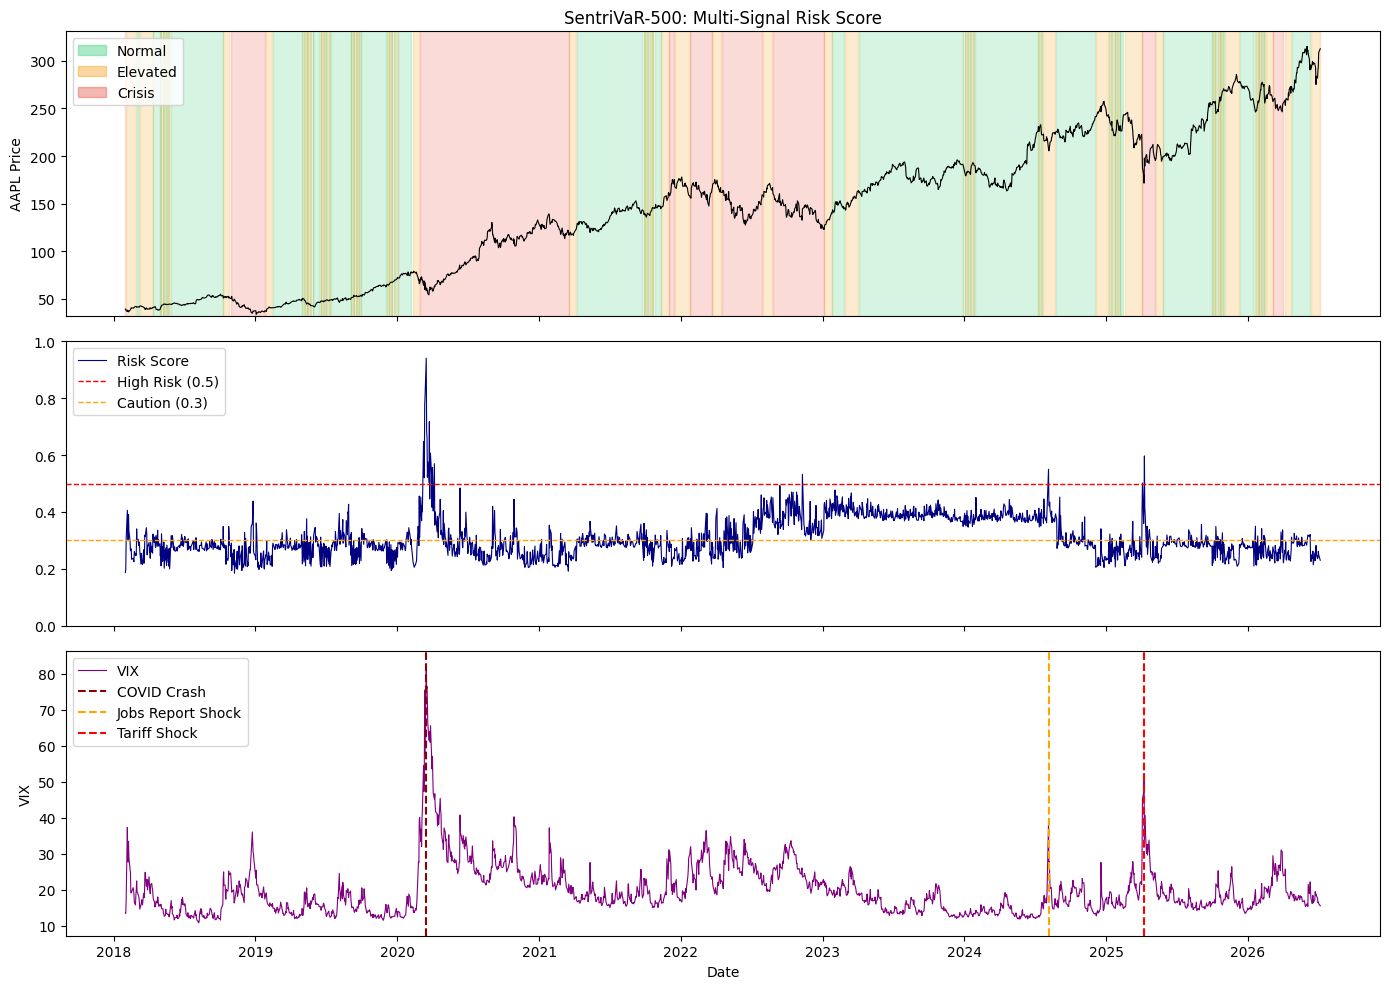

저장 완료: risk_score_final.png


In [4]:
# 국면별 리스크 점수 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors_map = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
labels_map = {0: "Normal", 1: "Elevated", 2: "Crisis"}

# 주가
ax1.plot(combined.index, prices["AAPL"].reindex(combined.index),
         color="black", linewidth=0.8)
ax1.set_ylabel("AAPL Price")
ax1.set_title("SentriVaR-500: Multi-Signal Risk Score")

# 국면 배경색
y_min = prices["AAPL"].reindex(combined.index).min() * 0.95
y_max = prices["AAPL"].reindex(combined.index).max() * 1.05
for state, color in colors_map.items():
    mask = combined["regime"] == state
    ax1.fill_between(combined.index, y_min, y_max,
                     where=mask.values, alpha=0.2, color=color)
ax1.set_ylim(y_min, y_max)

# 범례
patches = [mpatches.Patch(color=c, alpha=0.4, label=labels_map[s])
           for s, c in colors_map.items()]
ax1.legend(handles=patches, loc="upper left")

# 리스크 점수
ax2.plot(combined.index, combined["risk_score"],
         color="navy", linewidth=0.8, label="Risk Score")
ax2.axhline(0.5, color="red", linestyle="--", linewidth=1, label="High Risk (0.5)")
ax2.axhline(0.3, color="orange", linestyle="--", linewidth=1, label="Caution (0.3)")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper left")

# VIX
ax3.plot(combined.index, combined["VIX"],
         color="purple", linewidth=0.8, label="VIX")
ax3.axvline(pd.Timestamp("2020-03-16"), color="darkred",
            linestyle="--", linewidth=1.5, label="COVID Crash")
ax3.axvline(pd.Timestamp("2024-08-05"), color="orange",
            linestyle="--", linewidth=1.5, label="Jobs Report Shock")
ax3.axvline(pd.Timestamp("2025-04-07"), color="red",
            linestyle="--", linewidth=1.5, label="Tariff Shock")
ax3.set_ylabel("VIX")
ax3.set_xlabel("Date")
ax3.legend(loc="upper left")

plt.tight_layout()
plt.savefig(f"{data_path}/risk_score_final.png", dpi=150)
plt.show()
print("저장 완료: risk_score_final.png")

In [5]:
# 최종 리스크 점수 저장
combined[["regime", "regime_label", "VIX", "Spread", "risk_score"]].to_csv(
    f"{data_path}/final_risk_scores.csv"
)
print("저장 완료: final_risk_scores.csv")
print(f"\n현재 리스크 점수: {combined['risk_score'].iloc[-1]:.4f}")
print(f"현재 국면: {combined['regime_label'].iloc[-1]}")

저장 완료: final_risk_scores.csv

현재 리스크 점수: 0.2304
현재 국면: Elevated
